# IPL Match Winner Prediction - Training Pipeline

**Local conda env:**
- `conda create -n ipl python=3.11 -y` then `conda activate ipl`
- `pip install -r requirements.txt` (run from this project folder)
- Register the kernel (once): `python -m ipykernel install --user --name ipl --display-name "Python (ipl)"` then pick **Python (ipl)** in Cursor.

All data and models save under **`Datasets/`** and **`Models/`** in this project (`project_paths.py`). Optional: set env `IPL_PROJECT_ROOT` if your notebook cwd is not inside this folder.

This notebook downloads IPL data (2008-2025), derives player statistics from ball-by-ball data, performs EDA, engineers features, and trains an XGBoost model to predict match winners.

**Sections:**
1. Install & Import
2. Download Data
3. Build Player Stats
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Training
7. Model Comparison & Save

## 1. Install & Import

In [3]:
import subprocess
import sys
from pathlib import Path

_req = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / 'requirements.txt').is_file():
        _req = _p / 'requirements.txt'
        break
if _req:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(_req)])
else:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
        'pandas', 'numpy', 'scikit-learn', 'xgboost', 'matplotlib', 'seaborn', 'kagglehub', 'joblib'])
print('Dependencies OK (conda env: ipl).')

Dependencies OK (conda env: ipl).


In [5]:
import os
import sys
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Always use this repo's folders (not Jupyter's cwd when it differs)
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / 'project_paths.py').is_file():
        sys.path.insert(0, str(_p))
        break
from project_paths import ROOT, DATASET_DIR, MODEL_DIR

BASE_DIR = ROOT
DATASET_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {BASE_DIR}')
print(f'Datasets dir: {DATASET_DIR}')
print(f'Models dir:   {MODEL_DIR}')
print('Setup complete.')

ImportError: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

## 2. Download Data into Datasets/

In [ ]:
matches_path = DATASET_DIR / 'matches.csv'
deliveries_path = DATASET_DIR / 'deliveries.csv'

if matches_path.exists() and deliveries_path.exists():
    print('Datasets already exist, skipping download.')
else:
    try:
        import kagglehub
        path = kagglehub.dataset_download('maratheabhishek/ipl-dataset-2008-to-2025')
        print(f'Downloaded to: {path}')
        dl_path = Path(path)
        for f in dl_path.rglob('*.csv'):
            shutil.copy2(f, DATASET_DIR / f.name)
            print(f'  Copied {f.name}')

        # The dataset uses different file names -- rename to standard names
        rename_map = {
            'ipl_matches_data.csv': 'matches.csv',
            'ball_by_ball_data.csv': 'deliveries.csv',
        }
        for old_name, new_name in rename_map.items():
            src = DATASET_DIR / old_name
            dst = DATASET_DIR / new_name
            if src.exists() and not dst.exists():
                shutil.copy2(src, dst)
                print(f'  Mapped {old_name} -> {new_name}')
    except Exception as e:
        print(f'kagglehub failed: {e}')
        print('Download manually from: https://www.kaggle.com/datasets/maratheabhishek/ipl-dataset-2008-to-2025')
        print('Rename ipl_matches_data.csv -> matches.csv and ball_by_ball_data.csv -> deliveries.csv')

print('\nFiles in Datasets/:')
for f in sorted(DATASET_DIR.iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f'  {f.name}: {size_mb:.2f} MB')

Datasets already exist, skipping download.

Files in Datasets/:
  ball_by_ball_data.csv: 46.43 MB
  deliveries.csv: 46.43 MB
  ipl_matches_data.csv: 0.19 MB
  matches.csv: 0.19 MB
  players-data-updated.csv: 0.06 MB
  team_aliases.csv: 0.00 MB
  teams_data.csv: 0.00 MB


In [14]:
matches_raw = pd.read_csv(DATASET_DIR / 'matches.csv')
deliveries_raw = pd.read_csv(DATASET_DIR / 'deliveries.csv')

print(f'Matches: {matches_raw.shape[0]} rows, {matches_raw.shape[1]} columns')
print(f'Deliveries: {deliveries_raw.shape[0]} rows, {deliveries_raw.shape[1]} columns')
print('\n--- Matches columns ---')
print(matches_raw.columns.tolist())
print('\n--- Deliveries columns ---')
print(deliveries_raw.columns.tolist())

Matches: 1169 rows, 23 columns
Deliveries: 278205 rows, 30 columns

--- Matches columns ---
['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']

--- Deliveries columns ---
['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']


In [15]:
# Standardize column names to lowercase with underscores
matches_raw.columns = matches_raw.columns.str.strip().str.lower().str.replace(' ', '_')
deliveries_raw.columns = deliveries_raw.columns.str.strip().str.lower().str.replace(' ', '_')

# Common column name mappings (datasets vary in naming)
matches_col_map = {
    'match_id': 'id', 'matchid': 'id',
    'match_date': 'date', 'matchdate': 'date',
    'match_winner': 'winner', 'matchwinner': 'winner',
    'player_of_match': 'player_of_match', 'playerofmatch': 'player_of_match',
    'tosswin': 'toss_winner', 'tossdecision': 'toss_decision',
    'dl': 'dl_applied', 'dlapplied': 'dl_applied',
    'winbyrun': 'win_by_runs', 'winbyruns': 'win_by_runs',
    'winbywickets': 'win_by_wickets', 'winbywicket': 'win_by_wickets',
    'matchnumber': 'match_number',
}
deliveries_col_map = {
    'match_id': 'id', 'matchid': 'id',
    'over': 'overs', 'over_number': 'overs', 'ballnumber': 'ball_number', 'ball': 'ball_number',
    'batsmanrun': 'batsman_run', 'batsmanruns': 'batsman_run', 'batsman_runs': 'batsman_run',
    'batter_runs': 'batsman_run',
    'team_batting': 'batting_team', 'team_bowling': 'bowling_team',
    'extrarun': 'extra_run', 'extraruns': 'extra_run', 'extra_runs': 'extra_run',
    'totalrun': 'total_run', 'totalruns': 'total_run', 'total_runs': 'total_run',
    'iswicketdelivery': 'is_wicket', 'is_wicket_delivery': 'is_wicket',
    'playerout': 'player_out', 'player_dismissed': 'player_out',
    'dismissal_kind': 'kind', 'dismissalkind': 'kind',
    'fieldersinvolved': 'fielders_involved',
    'battingteam': 'batting_team', 'extra_type': 'extra_type', 'extratype': 'extra_type',
    'nonstriker': 'non_striker', 'non-striker': 'non_striker',
}

matches_raw.rename(columns=matches_col_map, inplace=True)
deliveries_raw.rename(columns=deliveries_col_map, inplace=True)

if 'date' not in matches_raw.columns and 'match_date' in matches_raw.columns:
    matches_raw.rename(columns={'match_date': 'date'}, inplace=True)
if 'winner' not in matches_raw.columns and 'match_winner' in matches_raw.columns:
    matches_raw.rename(columns={'match_winner': 'winner'}, inplace=True)

if 'is_wicket' in deliveries_raw.columns:
    deliveries_raw['is_wicket'] = deliveries_raw['is_wicket'].astype(int)

print('Standardized matches columns:', matches_raw.columns.tolist())
print('Standardized deliveries columns:', deliveries_raw.columns.tolist())

Standardized matches columns: ['id', 'season_id', 'balls_per_over', 'city', 'date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']
Standardized deliveries columns: ['season_id', 'id', 'batter', 'bowler', 'non_striker', 'batting_team', 'bowling_team', 'overs', 'ball_number', 'batsman_run', 'extras', 'total_run', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']


In [16]:
print('--- Matches sample ---')
display(matches_raw.head())
print('\n--- Matches info ---')
display(matches_raw.describe(include='all').T)

print('\n--- Deliveries sample ---')
display(deliveries_raw.head())

--- Matches sample ---


,id,season_id,balls_per_over,city,date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,36.0,win
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,57.0,win
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,71.0,win



--- Matches info ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1169.0,NaN,NaN,NaN,940835.248931,381924.446098,335982.0,548352.0,1082598.0,1304047.0,1485779.0
season_id,1169.0,NaN,NaN,NaN,2016.687767,5.2531,2008.0,2012.0,2017.0,2022.0,2025.0
balls_per_over,1169.0,NaN,NaN,NaN,6.0,0.0,6.0,6.0,6.0,6.0,6.0
city,1118,37,Mumbai,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1169,885,2025-04-27,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name,1169,1,Indian Premier League,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_number,1099.0,NaN,NaN,NaN,31.693358,18.497321,1.0,16.0,31.0,47.0,72.0
gender,1169,1,male,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,1169,1,T20,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
format,1169,1,T20,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Deliveries sample ---


,season_id,id,batter,bowler,non_striker,batting_team,bowling_team,overs,ball_number,batsman_run,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


## 3. Build Player Stats from Deliveries Data

Derive per-player cumulative IPL career stats and per-match stats directly from `deliveries.csv`. This covers every player who has ever played IPL (2008-2025) and lets us compute stats up to any date.

In [17]:
# Merge match date info into deliveries for temporal ordering
match_dates = matches_raw[['id', 'date', 'season']].copy()
match_dates['date'] = pd.to_datetime(match_dates['date'], errors='coerce')
deliveries = deliveries_raw.merge(match_dates, on='id', how='left')

# Identify bowling team for each delivery
match_teams = matches_raw[['id', 'team1', 'team2']].copy()
deliveries = deliveries.merge(match_teams, on='id', how='left')
deliveries['bowling_team'] = deliveries.apply(
    lambda r: r['team2'] if r['batting_team'] == r['team1'] else r['team1'], axis=1
)

print(f'Deliveries with dates: {deliveries.shape}')
deliveries.head()

Deliveries with dates: (278205, 34)


,season_id,id,batter,bowler,non_striker,batting_team,bowling_team,overs,ball_number,batsman_run,...,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings,date,season,team1,team2
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,1,0,0,NaN,False,1,2008-04-18,2008,1,6
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,0,0,0,NaN,False,1,2008-04-18,2008,1,6
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,0,0,0,NaN,False,1,2008-04-18,2008,1,6
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,0,0,0,NaN,False,1,2008-04-18,2008,1,6
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,0,0,0,NaN,False,1,2008-04-18,2008,1,6


In [18]:
# --- Per-player per-match BATTING stats ---
bat_match = deliveries.groupby(['id', 'date', 'season', 'batter', 'batting_team']).agg(
    runs_scored=('batsman_run', 'sum'),
    balls_faced=('batsman_run', 'count'),
    fours=('batsman_run', lambda x: (x == 4).sum()),
    sixes=('batsman_run', lambda x: (x == 6).sum()),
    dots_faced=('batsman_run', lambda x: (x == 0).sum()),
).reset_index()

bat_match['strike_rate'] = (bat_match['runs_scored'] / bat_match['balls_faced'].replace(0, np.nan)) * 100
bat_match['boundary_runs'] = bat_match['fours'] * 4 + bat_match['sixes'] * 6
bat_match['boundary_pct'] = bat_match['boundary_runs'] / bat_match['runs_scored'].replace(0, np.nan)
bat_match['dot_ball_pct'] = bat_match['dots_faced'] / bat_match['balls_faced'].replace(0, np.nan)

# Dismissals
dismissals = deliveries[deliveries['is_wicket'] == 1].groupby(['id', 'player_out']).size().reset_index(name='dismissed')
dismissals.rename(columns={'player_out': 'batter'}, inplace=True)
bat_match = bat_match.merge(dismissals, on=['id', 'batter'], how='left')
bat_match['dismissed'] = bat_match['dismissed'].fillna(0).astype(int)

bat_match.rename(columns={'batter': 'player', 'batting_team': 'team'}, inplace=True)

print(f'Batting match stats: {bat_match.shape}')
bat_match.head()

Batting match stats: (17638, 15)


,id,date,season,player,team,runs_scored,balls_faced,fours,sixes,dots_faced,strike_rate,boundary_runs,boundary_pct,dot_ball_pct,dismissed
0,335982,2008-04-18,2008,AA Noffke,1,9,12,1,0,6,75.000000,4,0.444444,0.500000,1
1,335982,2008-04-18,2008,B Akhil,1,0,2,0,0,2,0.000000,0,NaN,1.000000,1
2,335982,2008-04-18,2008,BB McCullum,6,158,77,10,13,23,205.194805,118,0.746835,0.298701,0
3,335982,2008-04-18,2008,CL White,1,6,10,0,0,5,60.000000,0,0.000000,0.500000,1
4,335982,2008-04-18,2008,DJ Hussey,6,12,12,1,0,4,100.000000,4,0.333333,0.333333,1


In [19]:
# --- Per-player per-match BOWLING stats ---
bowl_match = deliveries.groupby(['id', 'date', 'season', 'bowler', 'bowling_team']).agg(
    runs_conceded=('total_run', 'sum'),
    balls_bowled=('total_run', 'count'),
    wickets=('is_wicket', 'sum'),
    dots_bowled=('total_run', lambda x: (x == 0).sum()),
).reset_index()

bowl_match['overs_bowled'] = bowl_match['balls_bowled'] / 6
bowl_match['economy'] = bowl_match['runs_conceded'] / bowl_match['overs_bowled'].replace(0, np.nan)
bowl_match['bowling_sr'] = bowl_match['balls_bowled'] / bowl_match['wickets'].replace(0, np.nan)
bowl_match['dot_ball_bowl_pct'] = bowl_match['dots_bowled'] / bowl_match['balls_bowled'].replace(0, np.nan)

bowl_match.rename(columns={'bowler': 'player', 'bowling_team': 'team'}, inplace=True)

print(f'Bowling match stats: {bowl_match.shape}')
bowl_match.head()

Bowling match stats: (13846, 13)


,id,date,season,player,team,runs_conceded,balls_bowled,wickets,dots_bowled,overs_bowled,economy,bowling_sr,dot_ball_bowl_pct
0,335982,2008-04-18,2008,AA Noffke,1,41,25,1,6,4.166667,9.840000,25.000000,0.240000
1,335982,2008-04-18,2008,AB Agarkar,6,25,28,3,15,4.666667,5.357143,9.333333,0.535714
2,335982,2008-04-18,2008,AB Dinda,6,9,20,2,11,3.333333,2.700000,10.000000,0.550000
3,335982,2008-04-18,2008,CL White,1,24,7,0,0,1.166667,20.571429,NaN,0.000000
4,335982,2008-04-18,2008,I Sharma,6,13,19,1,10,3.166667,4.105263,19.000000,0.526316


In [20]:
# --- Combine into player_match_stats ---
player_match_stats = bat_match[['id', 'date', 'season', 'player', 'team',
    'runs_scored', 'balls_faced', 'strike_rate', 'fours', 'sixes',
    'boundary_pct', 'dot_ball_pct', 'dismissed']].merge(
    bowl_match[['id', 'player', 'runs_conceded', 'balls_bowled',
        'wickets', 'economy', 'bowling_sr', 'dot_ball_bowl_pct']],
    on=['id', 'player'], how='outer'
)

# Fill missing batting/bowling with 0 (player may only bat or only bowl in a match)
for col in ['runs_scored', 'balls_faced', 'fours', 'sixes', 'dismissed',
            'runs_conceded', 'balls_bowled', 'wickets']:
    player_match_stats[col] = player_match_stats[col].fillna(0).astype(int)

# Ensure date is populated from bat or bowl side
if player_match_stats['date'].isna().any():
    bowl_dates = bowl_match[['id', 'player', 'date', 'season', 'team']].rename(
        columns={'date': 'date_b', 'season': 'season_b', 'team': 'team_b'})
    player_match_stats = player_match_stats.merge(bowl_dates, on=['id', 'player'], how='left')
    player_match_stats['date'] = player_match_stats['date'].fillna(player_match_stats['date_b'])
    player_match_stats['season'] = player_match_stats['season'].fillna(player_match_stats['season_b'])
    player_match_stats['team'] = player_match_stats['team'].fillna(player_match_stats['team_b'])
    player_match_stats.drop(columns=['date_b', 'season_b', 'team_b'], inplace=True, errors='ignore')

player_match_stats['date'] = pd.to_datetime(player_match_stats['date'], errors='coerce')
player_match_stats.sort_values(['player', 'date', 'id'], inplace=True)
player_match_stats.reset_index(drop=True, inplace=True)

player_match_stats.to_csv(DATASET_DIR / 'player_match_stats.csv', index=False)
print(f'player_match_stats: {player_match_stats.shape}')
print(f'Unique players: {player_match_stats["player"].nunique()}')
player_match_stats.head(10)

player_match_stats: (25018, 19)
Unique players: 767


,id,date,season,player,team,runs_scored,balls_faced,strike_rate,fours,sixes,boundary_pct,dot_ball_pct,dismissed,runs_conceded,balls_bowled,wickets,economy,bowling_sr,dot_ball_bowl_pct
0,548341,2012-04-26,2012,A Ashish Reddy,2.0,0,0,NaN,0,0,NaN,NaN,0,32,24,2,8.000000,12.000000,0.250000
1,548346,2012-04-29,2012,A Ashish Reddy,2.0,10,10,100.0,0,1,0.600000,0.600000,1,11,14,1,4.714286,14.000000,0.571429
2,548348,2012-05-01,2012,A Ashish Reddy,2.0,0,0,NaN,0,0,NaN,NaN,0,32,19,1,10.105263,19.000000,0.157895
3,548352,2012-05-04,2012,A Ashish Reddy,2.0,3,3,100.0,0,0,0.000000,0.333333,1,16,13,1,7.384615,13.000000,0.230769
4,548356,2012-05-06,2012,A Ashish Reddy,2.0,0,0,NaN,0,0,NaN,NaN,0,36,25,1,8.640000,25.000000,0.440000
5,548359,2012-05-08,2012,A Ashish Reddy,2.0,8,8,100.0,1,0,0.500000,0.375000,1,40,25,2,9.600000,12.500000,0.280000
6,548329,2012-05-10,2012,A Ashish Reddy,2.0,0,0,NaN,0,0,NaN,NaN,0,29,12,0,14.500000,NaN,0.250000
7,548373,2012-05-18,2012,A Ashish Reddy,2.0,10,4,250.0,2,0,0.800000,0.250000,0,17,12,0,8.500000,NaN,0.333333
8,548376,2012-05-20,2012,A Ashish Reddy,2.0,4,5,80.0,0,0,0.000000,0.400000,1,25,25,3,6.000000,8.333333,0.400000
9,598000,2013-04-05,2013,A Ashish Reddy,2.0,7,4,175.0,1,0,0.571429,0.000000,0,21,12,1,10.500000,12.000000,0.166667


In [21]:
# --- Build cumulative player career stats (player_stats.csv) ---
player_stats = player_match_stats.groupby('player').agg(
    matches_played=('id', 'nunique'),
    total_runs=('runs_scored', 'sum'),
    total_balls_faced=('balls_faced', 'sum'),
    total_dismissals=('dismissed', 'sum'),
    total_fours=('fours', 'sum'),
    total_sixes=('sixes', 'sum'),
    total_wickets=('wickets', 'sum'),
    total_runs_conceded=('runs_conceded', 'sum'),
    total_balls_bowled=('balls_bowled', 'sum'),
).reset_index()

player_stats['batting_avg'] = player_stats['total_runs'] / player_stats['total_dismissals'].replace(0, np.nan)
player_stats['batting_sr'] = (player_stats['total_runs'] / player_stats['total_balls_faced'].replace(0, np.nan)) * 100
player_stats['boundary_pct'] = (
    (player_stats['total_fours'] * 4 + player_stats['total_sixes'] * 6)
    / player_stats['total_runs'].replace(0, np.nan)
)
player_stats['avg_runs_per_match'] = player_stats['total_runs'] / player_stats['matches_played']
player_stats['bowling_avg'] = player_stats['total_runs_conceded'] / player_stats['total_wickets'].replace(0, np.nan)
player_stats['bowling_econ'] = player_stats['total_runs_conceded'] / (player_stats['total_balls_bowled'] / 6).replace(0, np.nan)
player_stats['bowling_sr'] = player_stats['total_balls_bowled'] / player_stats['total_wickets'].replace(0, np.nan)
player_stats['ipl_experience'] = player_stats['matches_played']

player_stats.to_csv(DATASET_DIR / 'player_stats.csv', index=False)
print(f'Player stats: {player_stats.shape}')
print(f'\nTop 10 run scorers:')
display(player_stats.nlargest(10, 'total_runs')[['player', 'matches_played', 'total_runs', 'batting_avg', 'batting_sr']])
print(f'\nTop 10 wicket takers:')
display(player_stats.nlargest(10, 'total_wickets')[['player', 'matches_played', 'total_wickets', 'bowling_avg', 'bowling_econ']])

Player stats: (767, 18)

Top 10 run scorers:


,player,matches_played,total_runs,batting_avg,batting_sr
718,V Kohli,260,8671,39.593607,129.379290
544,RG Sharma,266,7048,29.864407,128.730594
582,S Dhawan,221,6769,35.072539,123.454313
163,DA Warner,184,6567,40.042683,135.429986
620,SK Raina,200,5536,32.374269,132.535312
421,MS Dhoni,241,5439,38.302817,132.626189
321,KL Rahul,135,5235,45.921053,132.632379
33,AB de Villiers,170,5181,39.853846,148.580442
53,AM Rahane,183,5032,30.496970,121.751754
137,CH Gayle,141,4997,39.658730,142.121729



Top 10 wicket takers:


,player,matches_played,total_wickets,bowling_avg,bowling_econ
756,YS Chahal,172,229,22.323144,7.854545
102,B Kumar,190,213,26.014085,7.593878
637,SP Narine,188,212,23.721698,6.825153
170,DJ Bravo,160,207,21.429952,8.075243
513,R Ashwin,217,205,27.907317,7.051356
278,JJ Bumrah,145,203,20.502463,7.188256
498,PP Chawla,192,201,25.766169,7.977920
624,SL Malinga,122,188,18.542553,7.032952
11,A Mishra,162,183,22.912568,7.304878
535,RA Jadeja,246,179,29.284916,7.621032


## 4. Exploratory Data Analysis

In [22]:
matches = matches_raw.copy()
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Drop matches with no result
matches_valid = matches.dropna(subset=['winner']).copy()
print(f'Total matches: {len(matches)}, Valid (with winner): {len(matches_valid)}')
print(f'Seasons: {sorted(matches_valid["season"].unique())}')
print(f'Teams: {sorted(matches_valid["team1"].unique())}')

Total matches: 1169, Valid (with winner): 1169
Seasons: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']
Teams: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(129), np.int64(134), np.int64(252), np.int64(494), np.int64(614), np.int64(615), np.int64(1414), np.int64(1419)]


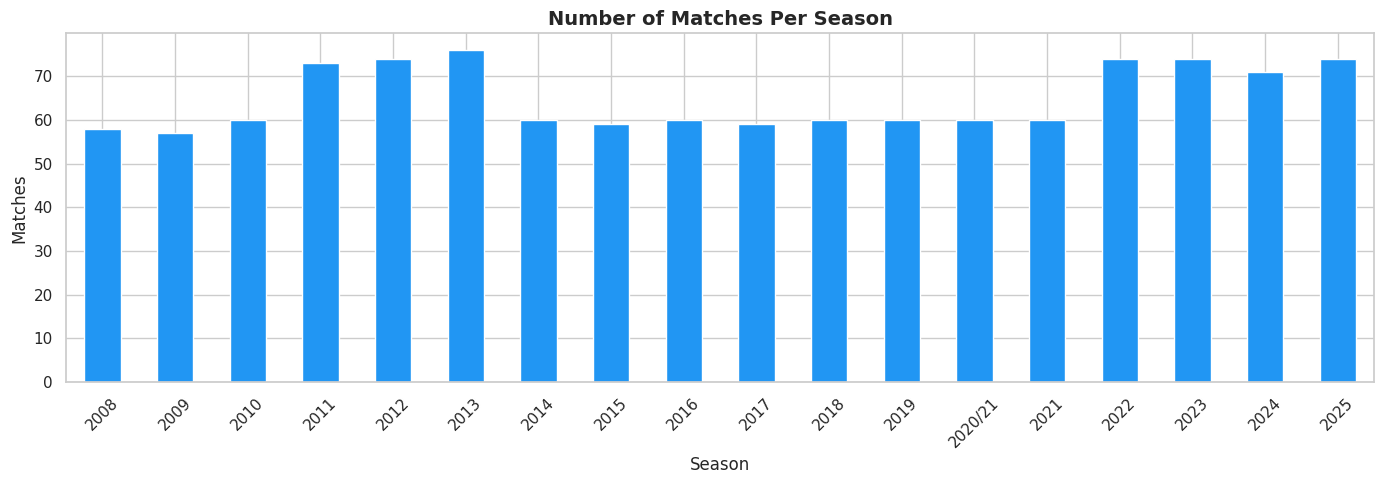

In [23]:
# Matches per season
fig, ax = plt.subplots(figsize=(14, 5))
matches_valid.groupby('season').size().plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('Number of Matches Per Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

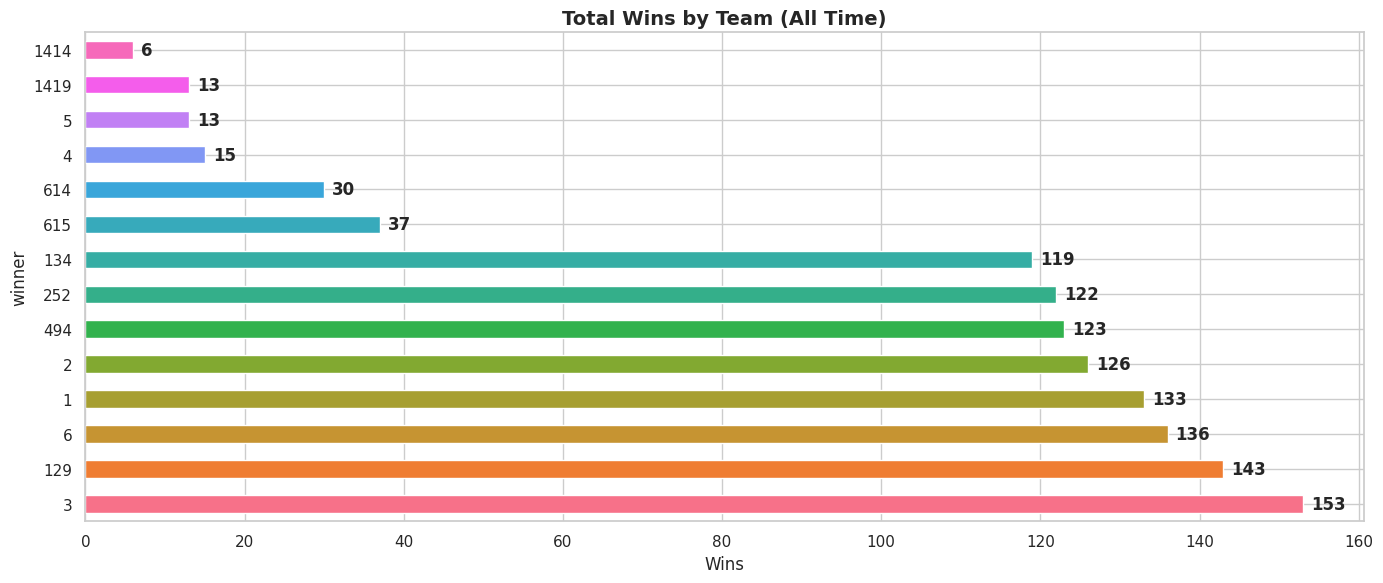

In [24]:
# Win distribution by team (all time)
win_counts = matches_valid['winner'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('husl', len(win_counts))
win_counts.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Total Wins by Team (All Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Wins')
for i, v in enumerate(win_counts.values):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

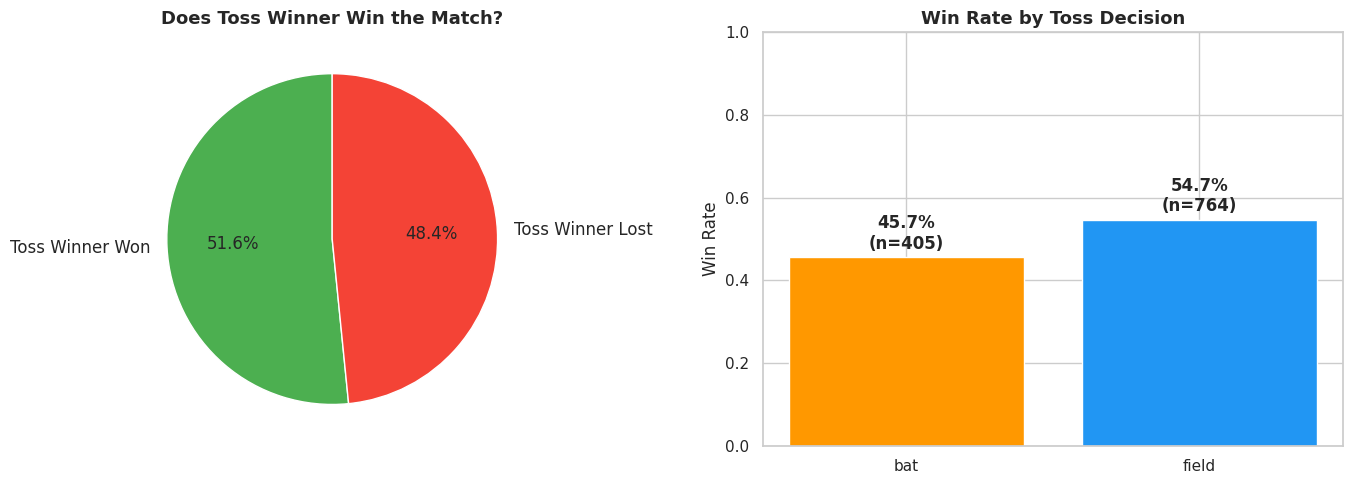

In [25]:
# Toss impact analysis
matches_valid['toss_winner_won'] = (matches_valid['toss_winner'] == matches_valid['winner']).astype(int)
toss_win_rate = matches_valid['toss_winner_won'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toss winner wins match?
labels = ['Toss Winner Won', 'Toss Winner Lost']
sizes = [toss_win_rate, 1 - toss_win_rate]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#4CAF50', '#f44336'],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Does Toss Winner Win the Match?', fontsize=13, fontweight='bold')

# Toss decision distribution
if 'toss_decision' in matches_valid.columns:
    td = matches_valid.groupby('toss_decision')['toss_winner_won'].agg(['mean', 'count']).reset_index()
    axes[1].bar(td['toss_decision'], td['mean'], color=['#FF9800', '#2196F3'], edgecolor='white')
    axes[1].set_title('Win Rate by Toss Decision', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Win Rate')
    axes[1].set_ylim(0, 1)
    for i, row in td.iterrows():
        axes[1].text(i, row['mean'] + 0.02, f"{row['mean']:.1%}\n(n={int(row['count'])})",
                     ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

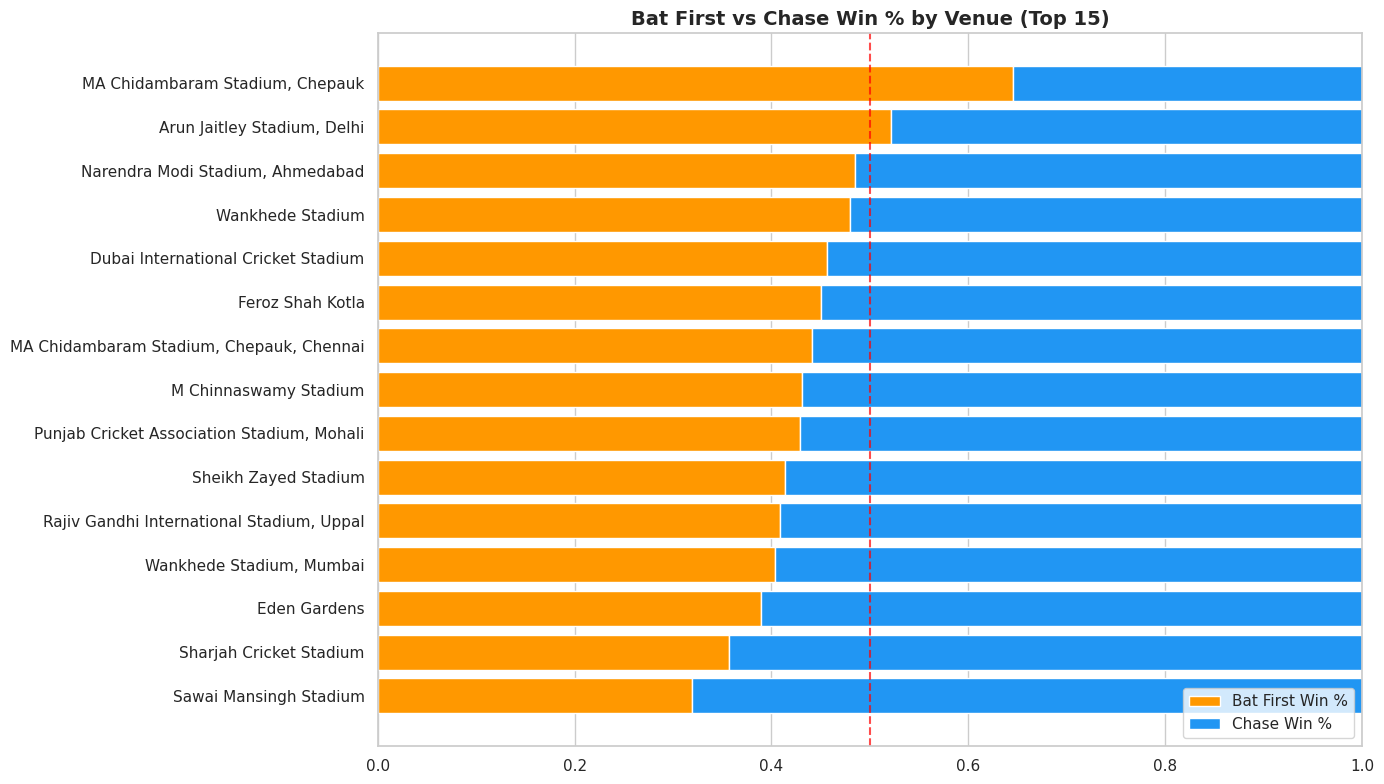

In [26]:
# Venue analysis: batting first vs chasing win %
venue_stats = matches_valid.copy()

# Determine if winner batted first or chased
first_innings_team = deliveries_raw.groupby('id').apply(
    lambda g: g[g['innings'] == 1]['batting_team'].iloc[0] if len(g[g['innings'] == 1]) > 0 else None
).reset_index(name='bat_first_team')
first_innings_team.columns = ['id', 'bat_first_team']

venue_stats = venue_stats.merge(first_innings_team, on='id', how='left')
venue_stats['winner_bat_first'] = (venue_stats['winner'] == venue_stats['bat_first_team']).astype(int)

top_venues = venue_stats['venue'].value_counts().head(15).index
venue_bat_first = venue_stats[venue_stats['venue'].isin(top_venues)].groupby('venue')['winner_bat_first'].agg(['mean', 'count']).reset_index()
venue_bat_first.columns = ['venue', 'bat_first_win_pct', 'total_matches']
venue_bat_first = venue_bat_first.sort_values('bat_first_win_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(venue_bat_first['venue'], venue_bat_first['bat_first_win_pct'],
               color='#FF9800', edgecolor='white', label='Bat First Win %')
ax.barh(venue_bat_first['venue'], 1 - venue_bat_first['bat_first_win_pct'],
        left=venue_bat_first['bat_first_win_pct'], color='#2196F3',
        edgecolor='white', label='Chase Win %')
ax.set_title('Bat First vs Chase Win % by Venue (Top 15)', fontsize=14, fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.7)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

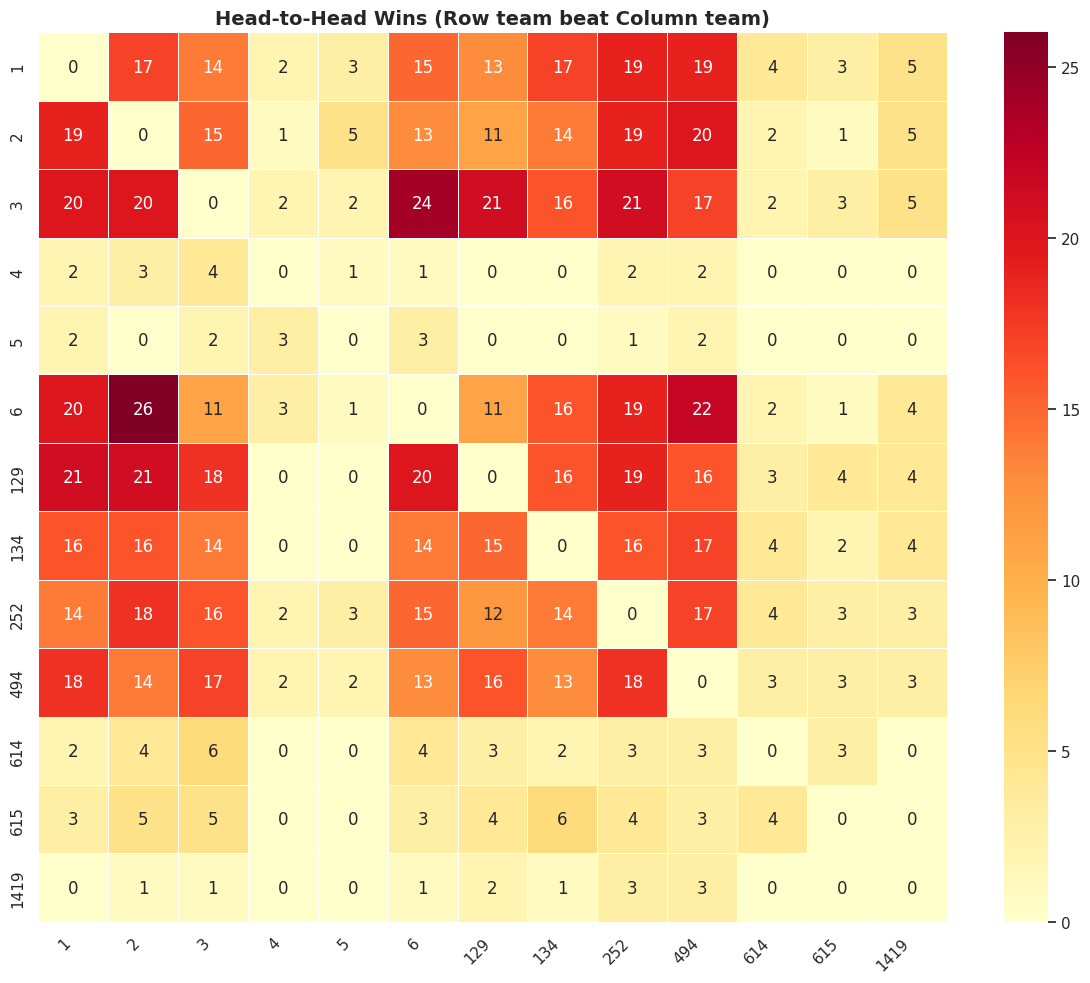

In [27]:
# Team head-to-head heatmap
current_teams = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru',
    'Royal Challengers Bangalore', 'Kolkata Knight Riders', 'Delhi Capitals',
    'Delhi Daredevils', 'Sunrisers Hyderabad', 'Rajasthan Royals',
    'Punjab Kings', 'Kings XI Punjab', 'Lucknow Super Giants', 'Gujarat Titans'
]

# Map old team names to current names
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}

h2h_df = matches_valid.copy()
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    h2h_df[col] = h2h_df[col].replace(team_name_map)

active_teams = sorted(set(h2h_df['team1'].unique()) & set(h2h_df['team2'].unique()) & set(h2h_df['winner'].unique()))
# Keep only teams with enough matches
team_match_counts = pd.concat([h2h_df['team1'], h2h_df['team2']]).value_counts()
active_teams = [t for t in active_teams if team_match_counts.get(t, 0) >= 20]

h2h_matrix = pd.DataFrame(0, index=active_teams, columns=active_teams, dtype=float)
for _, row in h2h_df.iterrows():
    t1, t2, w = row['team1'], row['team2'], row['winner']
    if t1 in active_teams and t2 in active_teams:
        if w == t1:
            h2h_matrix.loc[t1, t2] += 1
        elif w == t2:
            h2h_matrix.loc[t2, t1] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(h2h_matrix, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Head-to-Head Wins (Row team beat Column team)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

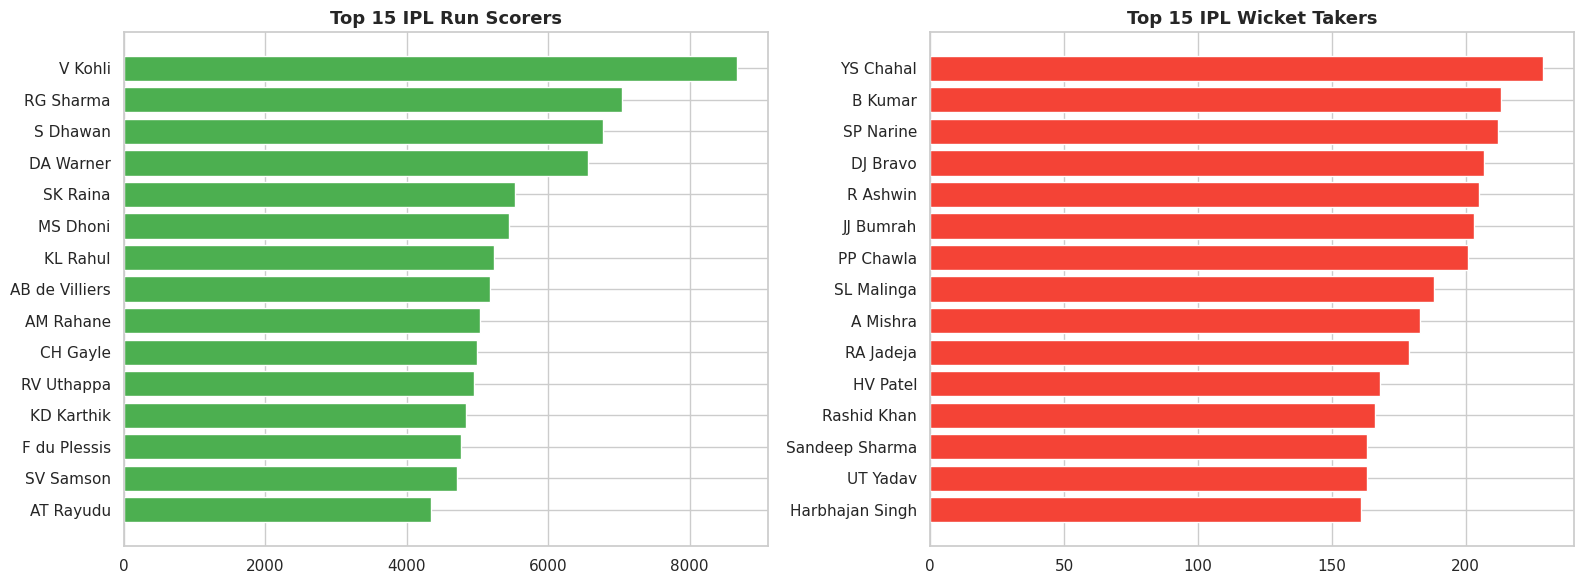

In [28]:
# Top players by impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_batters = player_stats.nlargest(15, 'total_runs')
axes[0].barh(top_batters['player'], top_batters['total_runs'], color='#4CAF50', edgecolor='white')
axes[0].set_title('Top 15 IPL Run Scorers', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

top_bowlers = player_stats.nlargest(15, 'total_wickets')
axes[1].barh(top_bowlers['player'], top_bowlers['total_wickets'], color='#f44336', edgecolor='white')
axes[1].set_title('Top 15 IPL Wicket Takers', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

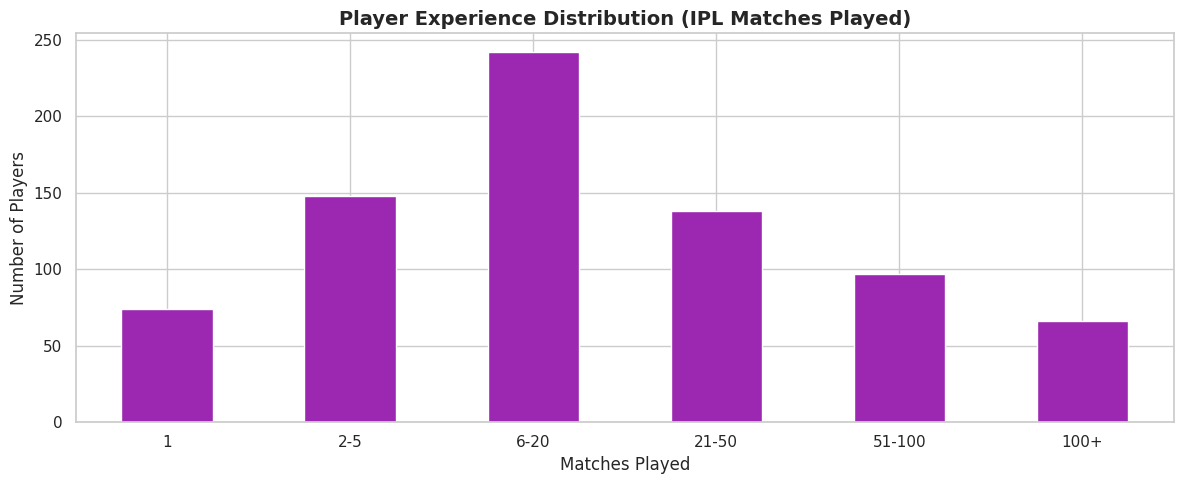

In [29]:
# Player experience distribution
fig, ax = plt.subplots(figsize=(12, 5))
exp_bins = [0, 1, 5, 20, 50, 100, 250]
exp_labels = ['1', '2-5', '6-20', '21-50', '51-100', '100+']
player_stats['exp_bucket'] = pd.cut(player_stats['matches_played'], bins=exp_bins, labels=exp_labels, right=True)
player_stats['exp_bucket'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#9C27B0', edgecolor='white')
ax.set_title('Player Experience Distribution (IPL Matches Played)', fontsize=14, fontweight='bold')
ax.set_xlabel('Matches Played')
ax.set_ylabel('Number of Players')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

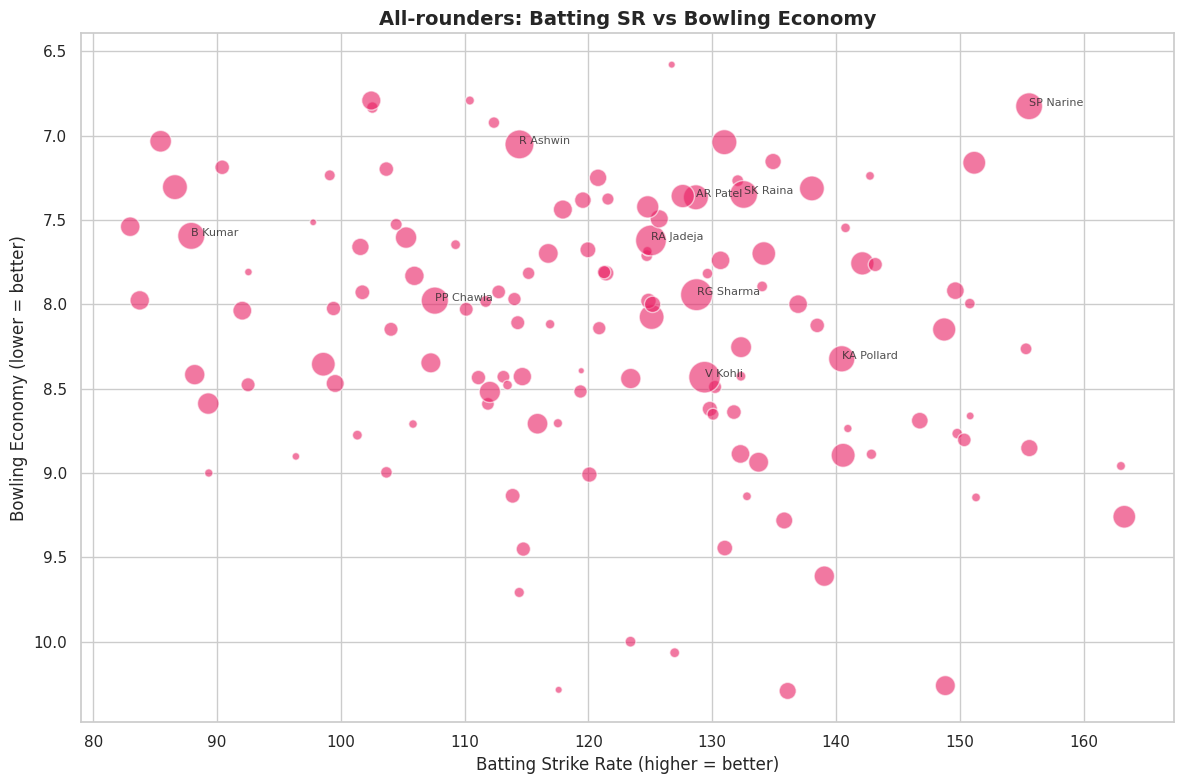

In [30]:
# Batting SR vs Bowling Economy scatter (players with enough matches)
allrounders = player_stats[(player_stats['total_balls_faced'] >= 100) & (player_stats['total_balls_bowled'] >= 100)].copy()

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(allrounders['batting_sr'], allrounders['bowling_econ'],
                     s=allrounders['matches_played'] * 2, alpha=0.6, c='#E91E63', edgecolor='white')

# Label top all-rounders
for _, row in allrounders.nlargest(10, 'matches_played').iterrows():
    ax.annotate(row['player'], (row['batting_sr'], row['bowling_econ']),
                fontsize=8, alpha=0.8)

ax.set_title('All-rounders: Batting SR vs Bowling Economy', fontsize=14, fontweight='bold')
ax.set_xlabel('Batting Strike Rate (higher = better)')
ax.set_ylabel('Bowling Economy (lower = better)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Feature Engineering

For each historical match, compute features using **only data available before that match** (strict temporal ordering to prevent data leakage).

In [31]:
# Prepare matches dataframe with standardized team names
df = matches_valid.copy()
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df[col] = df[col].replace(team_name_map)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'winner']).sort_values('date').reset_index(drop=True)

# Target: 1 if team1 wins, 0 if team2 wins
df['team1_wins'] = (df['team1'] == df['winner']).astype(int)

# Standardize player match stats team names too
pms = player_match_stats.copy()
pms['team'] = pms['team'].replace(team_name_map)
pms['date'] = pd.to_datetime(pms['date'], errors='coerce')

print(f'Building features for {len(df)} matches...')

Building features for 1169 matches...


In [32]:
def compute_team_form(df_history, team, n=5):
    """Rolling win rate and avg runs from last n matches for a team."""
    team_matches = df_history[(df_history['team1'] == team) | (df_history['team2'] == team)].copy()
    team_matches = team_matches.tail(n)
    if len(team_matches) == 0:
        return 0.5, 150.0  # defaults
    wins = ((team_matches['winner'] == team)).sum()
    win_rate = wins / len(team_matches)
    # Approximate avg runs from win margin
    avg_runs = 150.0  # sensible T20 default
    return win_rate, avg_runs

def compute_h2h(df_history, team1, team2):
    """Head-to-head record between two teams."""
    h2h = df_history[
        ((df_history['team1'] == team1) & (df_history['team2'] == team2)) |
        ((df_history['team1'] == team2) & (df_history['team2'] == team1))
    ]
    if len(h2h) == 0:
        return 0, 0, 0
    t1_wins = (h2h['winner'] == team1).sum()
    t2_wins = (h2h['winner'] == team2).sum()
    return t1_wins, t2_wins, len(h2h)

def compute_venue_stats(df_history, venue, team1, team2, first_innings_map):
    """Venue-level statistics."""
    v_matches = df_history[df_history['venue'] == venue]
    if len(v_matches) == 0:
        return 150.0, 0.5, 0.5, 0.5

    avg_first = 150.0  # default
    bat_first_wins = 0
    total = len(v_matches)
    for _, row in v_matches.iterrows():
        bf = first_innings_map.get(row['id'])
        if bf and row['winner'] == bf:
            bat_first_wins += 1
    bat_first_pct = bat_first_wins / total if total > 0 else 0.5

    t1_venue = v_matches[(v_matches['team1'] == team1) | (v_matches['team2'] == team1)]
    t1_venue_pct = (t1_venue['winner'] == team1).mean() if len(t1_venue) > 0 else 0.5
    t2_venue = v_matches[(v_matches['team1'] == team2) | (v_matches['team2'] == team2)]
    t2_venue_pct = (t2_venue['winner'] == team2).mean() if len(t2_venue) > 0 else 0.5

    return avg_first, bat_first_pct, t1_venue_pct, t2_venue_pct

def compute_toss_venue_win_pct(df_history, venue):
    """Win rate for toss winners at this venue."""
    v_matches = df_history[df_history['venue'] == venue]
    if len(v_matches) == 0:
        return 0.5
    return (v_matches['toss_winner'] == v_matches['winner']).mean()

def compute_player_team_strength(pms_history, team, match_date, n_recent=3):
    """Aggregate player stats for a team's recent squad."""
    team_players = pms_history[pms_history['team'] == team]
    if len(team_players) == 0:
        return {
            'avg_batting_sr': 125.0, 'avg_batting_avg': 25.0,
            'avg_bowling_econ': 8.0, 'avg_bowling_sr': 20.0,
            'total_experience': 0, 'new_player_count': 11,
            'avg_boundary_pct': 0.5,
            'recent_batting_sr': 125.0, 'recent_bowling_econ': 8.0,
        }

    # Get most recent squad (players who played in last 3 team matches)
    recent_team_match_ids = team_players.drop_duplicates('id').nlargest(3, 'date')['id'].unique()
    recent_squad = team_players[team_players['id'].isin(recent_team_match_ids)]['player'].unique()

    if len(recent_squad) == 0:
        recent_squad = team_players['player'].unique()[-11:]  # fallback

    squad_stats = team_players[team_players['player'].isin(recent_squad)]

    # Cumulative stats per player
    player_cum = squad_stats.groupby('player').agg(
        total_runs=('runs_scored', 'sum'),
        total_balls=('balls_faced', 'sum'),
        total_dismissals=('dismissed', 'sum'),
        total_wickets=('wickets', 'sum'),
        total_runs_conceded=('runs_conceded', 'sum'),
        total_balls_bowled=('balls_bowled', 'sum'),
        matches=('id', 'nunique'),
    ).reset_index()

    player_cum['batting_sr'] = (player_cum['total_runs'] / player_cum['total_balls'].replace(0, np.nan)) * 100
    player_cum['batting_avg'] = player_cum['total_runs'] / player_cum['total_dismissals'].replace(0, np.nan)
    player_cum['bowling_econ'] = player_cum['total_runs_conceded'] / (player_cum['total_balls_bowled'] / 6).replace(0, np.nan)
    player_cum['bowling_sr'] = player_cum['total_balls_bowled'] / player_cum['total_wickets'].replace(0, np.nan)
    player_cum['boundary_pct'] = (
        squad_stats.groupby('player')['boundary_pct'].mean().reindex(player_cum['player']).values
    )

    # Recent form: last n_recent innings per player
    recent_form = []
    for p in recent_squad:
        p_data = squad_stats[squad_stats['player'] == p].tail(n_recent)
        if len(p_data) > 0 and p_data['balls_faced'].sum() > 0:
            recent_form.append({
                'batting_sr': (p_data['runs_scored'].sum() / p_data['balls_faced'].sum()) * 100,
                'bowling_econ': p_data['economy'].mean() if p_data['balls_bowled'].sum() > 0 else np.nan,
            })
    recent_df = pd.DataFrame(recent_form)

    return {
        'avg_batting_sr': player_cum['batting_sr'].mean() or 125.0,
        'avg_batting_avg': player_cum['batting_avg'].mean() or 25.0,
        'avg_bowling_econ': player_cum['bowling_econ'].mean() or 8.0,
        'avg_bowling_sr': player_cum['bowling_sr'].mean() or 20.0,
        'total_experience': int(player_cum['matches'].sum()),
        'new_player_count': int((player_cum['matches'] <= 1).sum()),
        'avg_boundary_pct': player_cum['boundary_pct'].mean() or 0.5,
        'recent_batting_sr': recent_df['batting_sr'].mean() if len(recent_df) > 0 else 125.0,
        'recent_bowling_econ': recent_df['bowling_econ'].mean() if len(recent_df) > 0 else 8.0,
    }

print('Feature functions defined.')

Feature functions defined.


In [33]:
# Build first-innings map for venue stats
first_innings_map = {}
for mid, group in deliveries_raw.groupby('id'):
    inn1 = group[group['innings'] == 1]
    if len(inn1) > 0:
        bt_col = 'batting_team' if 'batting_team' in inn1.columns else None
        if bt_col:
            team = inn1[bt_col].iloc[0]
            # Standardize name
            first_innings_map[mid] = team_name_map.get(team, team)

print(f'First innings map built for {len(first_innings_map)} matches.')

First innings map built for 1169 matches.


In [34]:
# --- Build feature matrix ---
# This takes a few minutes due to rolling computations

feature_rows = []
total = len(df)

for idx in range(total):
    row = df.iloc[idx]
    match_date = row['date']
    team1, team2, venue = row['team1'], row['team2'], row['venue']

    # History = all matches strictly before this one
    history = df.iloc[:idx]
    pms_hist = pms[pms['date'] < match_date]

    # Team form
    t1_wr, t1_avg_runs = compute_team_form(history, team1, n=5)
    t2_wr, t2_avg_runs = compute_team_form(history, team2, n=5)

    # Head-to-head
    h2h_t1, h2h_t2, h2h_total = compute_h2h(history, team1, team2)

    # Venue
    v_avg_first, v_bat_first_pct, v_t1_pct, v_t2_pct = compute_venue_stats(
        history, venue, team1, team2, first_innings_map)

    # Toss
    toss_is_team1 = 1 if row.get('toss_winner') == team1 else 0
    toss_decision_bat = 1 if str(row.get('toss_decision', '')).lower() in ['bat', 'batting'] else 0
    toss_venue_pct = compute_toss_venue_win_pct(history, venue)

    # Player-based team strength
    t1_strength = compute_player_team_strength(pms_hist, team1, match_date)
    t2_strength = compute_player_team_strength(pms_hist, team2, match_date)

    # Season / context
    season_num = row.get('season', 2020)
    is_playoff = 1 if str(row.get('match_number', '')).lower() in [
        'qualifier 1', 'qualifier 2', 'eliminator', 'final',
        'qualifier', 'elimination final', '3rd place play-off'
    ] else 0

    feat = {
        'team1_win_rate_last5': t1_wr,
        'team2_win_rate_last5': t2_wr,
        'h2h_team1_wins': h2h_t1,
        'h2h_team2_wins': h2h_t2,
        'h2h_total': h2h_total,
        'venue_bat_first_win_pct': v_bat_first_pct,
        'venue_team1_win_pct': v_t1_pct,
        'venue_team2_win_pct': v_t2_pct,
        'toss_winner_is_team1': toss_is_team1,
        'toss_decision_bat': toss_decision_bat,
        'toss_venue_win_pct': toss_venue_pct,
        # Team 1 player strength
        'team1_avg_batting_sr': t1_strength['avg_batting_sr'],
        'team1_avg_batting_avg': t1_strength['avg_batting_avg'],
        'team1_avg_bowling_econ': t1_strength['avg_bowling_econ'],
        'team1_avg_bowling_sr': t1_strength['avg_bowling_sr'],
        'team1_total_experience': t1_strength['total_experience'],
        'team1_new_player_count': t1_strength['new_player_count'],
        'team1_boundary_pct': t1_strength['avg_boundary_pct'],
        'team1_recent_batting_sr': t1_strength['recent_batting_sr'],
        'team1_recent_bowling_econ': t1_strength['recent_bowling_econ'],
        # Team 2 player strength
        'team2_avg_batting_sr': t2_strength['avg_batting_sr'],
        'team2_avg_batting_avg': t2_strength['avg_batting_avg'],
        'team2_avg_bowling_econ': t2_strength['avg_bowling_econ'],
        'team2_avg_bowling_sr': t2_strength['avg_bowling_sr'],
        'team2_total_experience': t2_strength['total_experience'],
        'team2_new_player_count': t2_strength['new_player_count'],
        'team2_boundary_pct': t2_strength['avg_boundary_pct'],
        'team2_recent_batting_sr': t2_strength['recent_batting_sr'],
        'team2_recent_bowling_econ': t2_strength['recent_bowling_econ'],
        # Context
        'season': season_num,
        'is_playoff': is_playoff,
        # Target
        'team1_wins': row['team1_wins'],
        # Meta (not used as features)
        '_match_id': row['id'],
        '_team1': team1,
        '_team2': team2,
        '_venue': venue,
        '_date': str(match_date),
    }
    feature_rows.append(feat)

    if (idx + 1) % 100 == 0:
        print(f'  Processed {idx + 1}/{total} matches...')

features_df = pd.DataFrame(feature_rows)
print(f'\nFeature matrix: {features_df.shape}')
features_df.head()

  Processed 100/1169 matches...
  Processed 200/1169 matches...
  Processed 300/1169 matches...
  Processed 400/1169 matches...
  Processed 500/1169 matches...
  Processed 600/1169 matches...
  Processed 700/1169 matches...
  Processed 800/1169 matches...
  Processed 900/1169 matches...
  Processed 1000/1169 matches...
  Processed 1100/1169 matches...

Feature matrix: (1169, 37)


,team1_win_rate_last5,team2_win_rate_last5,h2h_team1_wins,h2h_team2_wins,h2h_total,venue_bat_first_win_pct,venue_team1_win_pct,venue_team2_win_pct,toss_winner_is_team1,toss_decision_bat,...,team2_recent_batting_sr,team2_recent_bowling_econ,season,is_playoff,team1_wins,_match_id,_team1,_team2,_venue,_date
0,0.5,0.5,0,0,0,0.5,0.5,0.5,1,0,...,125.000000,8.000000,2008,0,0,335982,1,6,M Chinnaswamy Stadium,2008-04-18 00:00:00
1,0.5,0.5,0,0,0,0.5,0.5,0.5,0,1,...,125.000000,8.000000,2008,0,1,335984,252,134,Feroz Shah Kotla,2008-04-19 00:00:00
2,0.5,0.5,0,0,0,0.5,0.5,0.5,0,1,...,125.000000,8.000000,2008,0,0,335983,494,129,"Punjab Cricket Association Stadium, Mohali",2008-04-19 00:00:00
3,0.5,0.0,0,0,0,0.5,0.5,0.5,1,1,...,55.800403,11.816349,2008,0,0,335985,3,1,Wankhede Stadium,2008-04-20 00:00:00
4,1.0,0.5,0,0,0,0.5,0.5,0.5,0,1,...,125.000000,8.000000,2008,0,1,335986,6,2,Eden Gardens,2008-04-20 00:00:00


In [36]:
# Handle NaN/Inf values
feature_cols = [c for c in features_df.columns if not c.startswith('_') and c != 'team1_wins']

X_feat = features_df[feature_cols].replace([np.inf, -np.inf], np.nan)
# season (and others) may be object strings from CSV -- coerce before median
for c in X_feat.columns:
    X_feat[c] = pd.to_numeric(X_feat[c], errors='coerce')
X_feat = X_feat.fillna(X_feat.median(numeric_only=True))
features_df[feature_cols] = X_feat

print(f'Feature columns ({len(feature_cols)}):')
print(feature_cols)
print(f'\nNaN remaining: {features_df[feature_cols].isna().sum().sum()}')
print(f'Target distribution:\n{features_df["team1_wins"].value_counts()}')

Feature columns (31):
['team1_win_rate_last5', 'team2_win_rate_last5', 'h2h_team1_wins', 'h2h_team2_wins', 'h2h_total', 'venue_bat_first_win_pct', 'venue_team1_win_pct', 'venue_team2_win_pct', 'toss_winner_is_team1', 'toss_decision_bat', 'toss_venue_win_pct', 'team1_avg_batting_sr', 'team1_avg_batting_avg', 'team1_avg_bowling_econ', 'team1_avg_bowling_sr', 'team1_total_experience', 'team1_new_player_count', 'team1_boundary_pct', 'team1_recent_batting_sr', 'team1_recent_bowling_econ', 'team2_avg_batting_sr', 'team2_avg_batting_avg', 'team2_avg_bowling_econ', 'team2_avg_bowling_sr', 'team2_total_experience', 'team2_new_player_count', 'team2_boundary_pct', 'team2_recent_batting_sr', 'team2_recent_bowling_econ', 'season', 'is_playoff']

NaN remaining: 0
Target distribution:
team1_wins
0    588
1    581
Name: count, dtype: int64


## 6. Model Training

Train on 2008-2024, test on 2025 season.

In [37]:
# Split: train on all seasons before 2025, test on 2025
train_mask = features_df['season'].astype(int) < 2025
test_mask = features_df['season'].astype(int) == 2025

X_train = features_df.loc[train_mask, feature_cols].values
y_train = features_df.loc[train_mask, 'team1_wins'].values
X_test = features_df.loc[test_mask, feature_cols].values
y_test = features_df.loc[test_mask, 'team1_wins'].values

print(f'Train: {X_train.shape[0]} matches (2008-2024)')
print(f'Test:  {X_test.shape[0]} matches (2025)')
print(f'Train target balance: {y_train.mean():.2%} team1 wins')
print(f'Test target balance:  {y_test.mean():.2%} team1 wins')

Train: 1095 matches (2008-2024)
Test:  74 matches (2025)
Train target balance: 50.05% team1 wins
Test target balance:  44.59% team1 wins


In [38]:
# --- Model 1: Logistic Regression (baseline) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'Logistic Regression:')
print(f'  Accuracy: {lr_acc:.4f}')
print(f'  F1 Score: {lr_f1:.4f}')
print(f'  ROC-AUC:  {lr_auc:.4f}')

Logistic Regression:
  Accuracy: 0.5541
  F1 Score: 0.4762
  ROC-AUC:  0.5595


In [39]:
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f'Random Forest:')
print(f'  Accuracy: {rf_acc:.4f}')
print(f'  F1 Score: {rf_f1:.4f}')
print(f'  ROC-AUC:  {rf_auc:.4f}')

Random Forest:
  Accuracy: 0.5676
  F1 Score: 0.4839
  ROC-AUC:  0.5602


In [40]:
# --- Model 3: XGBoost with hyperparameter tuning ---
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring='accuracy',
    n_jobs=-1, verbose=1, refit=True
)
grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV accuracy: 0.5525


In [41]:
# Evaluate best XGBoost on test set
xgb_best = grid_search.best_estimator_

xgb_preds = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f'XGBoost (tuned):')
print(f'  Accuracy: {xgb_acc:.4f}')
print(f'  F1 Score: {xgb_f1:.4f}')
print(f'  ROC-AUC:  {xgb_auc:.4f}')

XGBoost (tuned):
  Accuracy: 0.5135
  F1 Score: 0.4545
  ROC-AUC:  0.5410


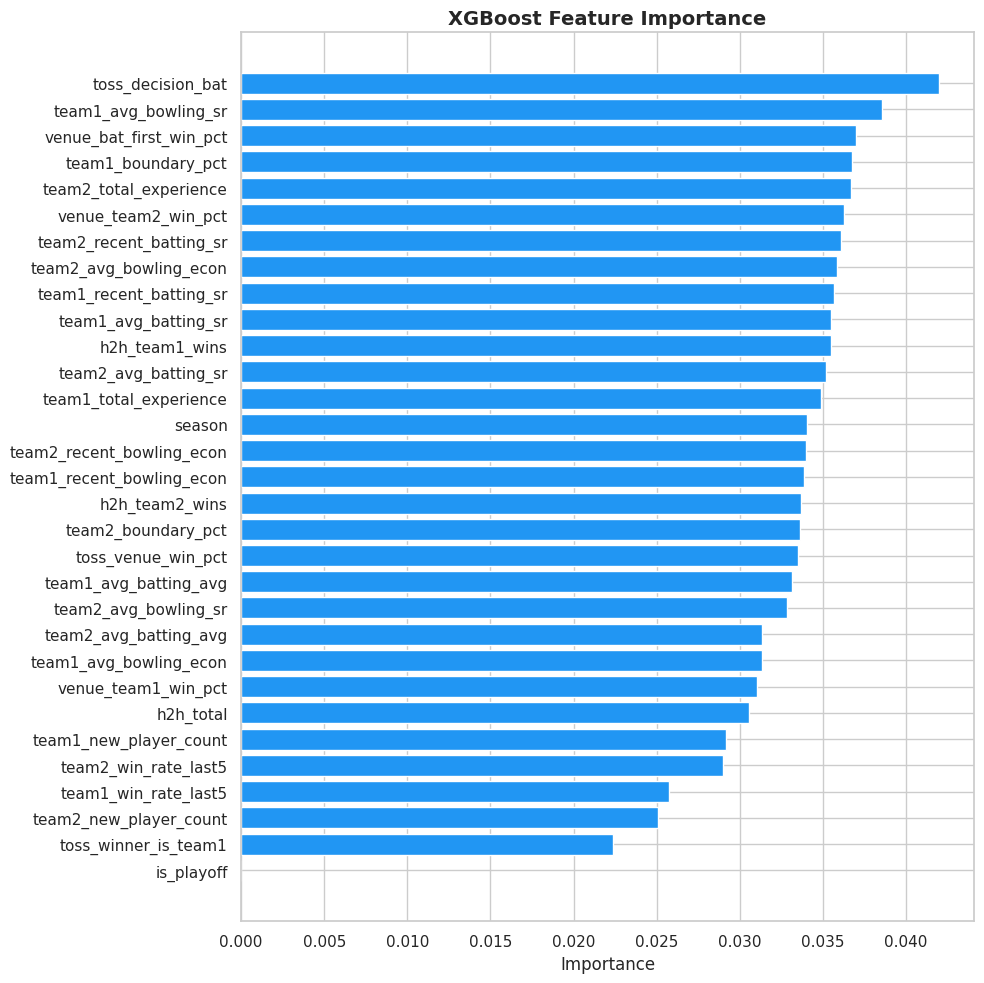

In [42]:
# Feature importance from XGBoost
importances = xgb_best.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='#2196F3', edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Model Comparison & Save

In [43]:
# --- Side-by-side comparison ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (tuned)'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'F1 Score': [lr_f1, rf_f1, xgb_f1],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc],
})

print('=== Model Comparison on 2025 Season Test Set ===')
display(results.style.highlight_max(subset=['Accuracy', 'F1 Score', 'ROC-AUC'],
                                     color='lightgreen'))

=== Model Comparison on 2025 Season Test Set ===


,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.554054,0.476190,0.559497
1,Random Forest,0.567568,0.483871,0.560237
2,XGBoost (tuned),0.513514,0.454545,0.541020


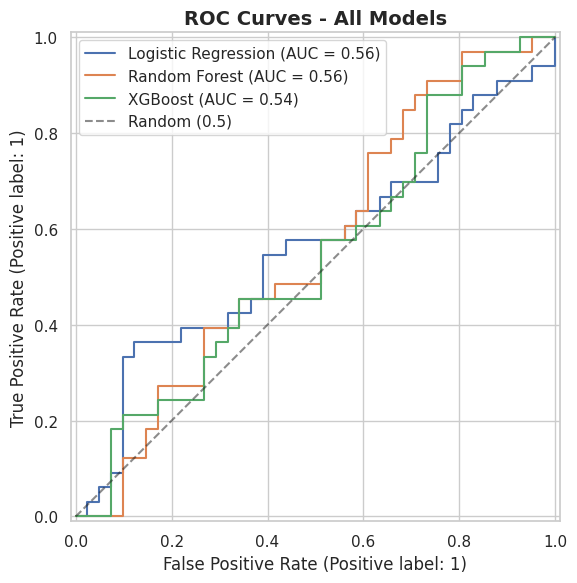

In [44]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=ax)
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (0.5)')
ax.legend()
plt.tight_layout()
plt.show()

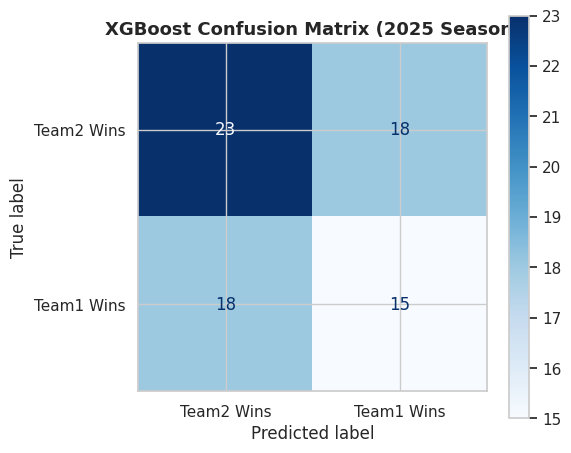


Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.56      0.56      0.56        41
  Team1 Wins       0.45      0.45      0.45        33

    accuracy                           0.51        74
   macro avg       0.51      0.51      0.51        74
weighted avg       0.51      0.51      0.51        74



In [45]:
# Confusion matrix for best model (XGBoost)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds,
    display_labels=['Team2 Wins', 'Team1 Wins'], cmap='Blues', ax=ax)
ax.set_title('XGBoost Confusion Matrix (2025 Season)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=['Team2 Wins', 'Team1 Wins']))

In [47]:
# --- Save the best model and artifacts (local project Models/ folder) ---
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_best, MODEL_DIR / 'xgb_ipl_model.pkl')
joblib.dump(feature_cols, MODEL_DIR / 'feature_columns.pkl')
joblib.dump(team_name_map, MODEL_DIR / 'team_name_map.pkl')
features_df.to_csv(DATASET_DIR / 'features_matrix.csv', index=False)

print(f'Files written under: {MODEL_DIR.resolve()}')
for f in sorted(MODEL_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name}: {f.stat().st_size / 1024:.1f} KB')

print(f'\n=== Training Complete ===')
print(f'Best model: XGBoost')
print(f'Test accuracy (2025 season): {xgb_acc:.2%}')
print(f'Features used: {len(feature_cols)}')
print('Artifacts saved on disk in this project (see paths above).')

Files written here (absolute path): /content/Models
  feature_columns.pkl: 0.7 KB
  team_name_map.pkl: 0.1 KB
  xgb_ipl_model.pkl: 614.0 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded ipl_models.zip — on Windows, unzip into your project and put the .pkl files in Models/.

=== Training Complete ===
Best model: XGBoost
Test accuracy (2025 season): 51.35%
Features used: 31
If you trained on Colab: copy Models/*.pkl and Datasets/*.csv to your Windows project, or use the zip download.
